In [11]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv("test.csv")   # your file
print(data.head())
print(data.columns)

                                                text  label
0  im feeling rather rotten so im not very ambiti...      0
1          im updating my blog because i feel shitty      0
2  i never make her separate from me because i do...      0
3  i left with my bouquet of red and yellow tulip...      1
4    i was feeling a little vain when i did this one      0
Index(['text', 'label'], dtype='object')


0 → Sad
1 → Happy
2 → Love (remove)
3 → Angry
4 → Fear
5 → Surprise (remove)

In [13]:
allowed_labels = [0, 1, 3, 4]
data = data[data["label"].isin(allowed_labels)].copy()

In [14]:
label_map = {
    1: 0,  # Happy
    0: 1,  # Sad
    3: 2,  # Angry
    4: 3   # Fear
}

data["label"] = data["label"].replace(label_map).astype(int)

In [15]:
print(data["label"].value_counts())

label
0    695
1    581
2    275
3    224
Name: count, dtype: int64


In [16]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

data["clean_text"] = data["text"].apply(clean_text)

In [17]:
happy_words = ["happy","joy","smile","excited","cheerful"]
sad_words = ["sad","cry","lonely","depressed","down"]
angry_words = ["angry","hate","furious","rage","annoyed"]
fear_words = ["fear","scared","terrified","nervous","anxious"]

def lexicon_features(text):
    words = text.split()
    return [
        sum(w in happy_words for w in words),
        sum(w in sad_words for w in words),
        sum(w in angry_words for w in words),
        sum(w in fear_words for w in words)
    ]

lex_df = pd.DataFrame(
    data["clean_text"].apply(lexicon_features).tolist(),
    columns=["happy_count","sad_count","angry_count","fear_count"]
)

In [18]:
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(data["clean_text"])

In [19]:
X = hstack([X_tfidf, lex_df])
y = data["label"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [21]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.6084507042253521
              precision    recall  f1-score   support

           0       0.57      0.95      0.71       139
           1       0.68      0.65      0.66       116
           2       0.50      0.04      0.07        55
           3       0.78      0.16      0.26        45

    accuracy                           0.61       355
   macro avg       0.63      0.45      0.43       355
weighted avg       0.62      0.61      0.54       355



In [22]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.704225352112676
              precision    recall  f1-score   support

           0       0.73      0.78      0.75       139
           1       0.71      0.68      0.70       116
           2       0.60      0.56      0.58        55
           3       0.74      0.69      0.71        45

    accuracy                           0.70       355
   macro avg       0.69      0.68      0.69       355
weighted avg       0.70      0.70      0.70       355



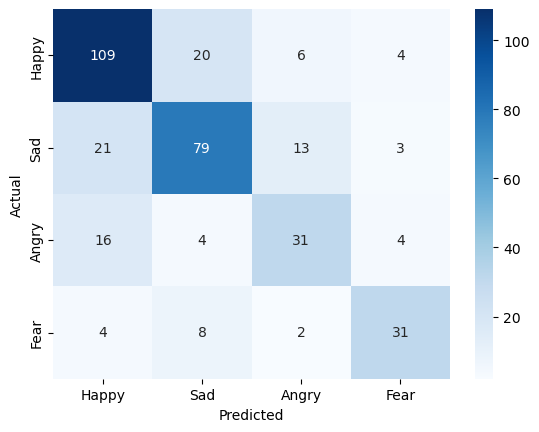

In [23]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Happy","Sad","Angry","Fear"],
            yticklabels=["Happy","Sad","Angry","Fear"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
emotion_labels = {
    0: "Happy",
    1: "Sad",
    2: "Angry",
    3: "Fear"
}

In [25]:
def predict_emotion(text):
    cleaned = clean_text(text)
    text_tfidf = tfidf.transform([cleaned])
    lex_feat = lexicon_features(cleaned)
    final_features = hstack([text_tfidf, lex_feat])
    
    prediction = lr.predict(final_features)[0]
    
    return emotion_labels[int(prediction)]

In [ ]:
user_text = input("Enter a sentence: ")
print("Predicted Emotion:", predict_emotion(user_text))

In [ ]:
user_text = input("Enter a sentence: ")
print("Predicted Emotion:", predict_emotion(user_text))

Enter a sentence:  I feel scared and nervous


Predicted Emotion: Fear


In [ ]:
user_text = input("Enter a sentence: ")
print("Predicted Emotion:", predict_emotion(user_text))

Enter a sentence:  This makes me so annoyed


Predicted Emotion: Angry


In [ ]:
user_text = input("Enter a sentence: ")
print("Predicted Emotion:", predict_emotion(user_text))

Enter a sentence:  this is bad


Predicted Emotion: Sad
